In [37]:
import numpy as np
from matplotlib import pyplot as plt


In [38]:
# 環境のパラメータ
g = 9.80665  # gravity [m/s^2]
rho = 1.225  # air density [kg/m^3]

# 機体 (TechPod) のパラメータ
m = 2.75  # mass [kg]
S = 0.47  # wing surface [m^2]
c_lift_0 = 0.2127
c_lift_alpha = 10.806
c_drag_0 = 0.136
c_drag_alpha = 0.6737

# 1次遅れ要素
zeta = np.sqrt(0.5)  # 減衰定数
omega_n = 1.  # 自然周波数

# 現在の状態と目標の状態
cur_V = 10  # [m/s]
cur_gamma = np.deg2rad(0)  # [rad]
tar_V = 15  # [m/s]
tar_gamma_rate = np.deg2rad(30)  # [rad/s]
tar_yaw_rate = np.deg2rad(30)  # [rad/s]


In [39]:
# G: 地面座標系．z軸のみ機体座標系と一致し，x,y軸は世界座標系と一致している．
# A: 空気座標系．静止空気を仮定しているため，地面座標系をY軸周りにgammaだけ回転させた座標系に等しい．
G_rot_A = np.array([
    [np.cos(cur_gamma), 0, np.sin(cur_gamma)],
    [0, 1, 0],
    [-np.sin(cur_gamma), 0, np.cos(cur_gamma)],
])

A_cur_v = np.array([cur_V, 0, 0])
cur_v_x, cur_v_y, cur_v_z = G_rot_A @ A_cur_v

kv = 2 * zeta * omega_n
A_tar_a = np.array([
    kv * (tar_V - cur_V),
    cur_V * np.cos(cur_gamma) * tar_yaw_rate,
    -cur_V * tar_gamma_rate,
])
tar_a_x, tar_a_y, tar_a_z = G_rot_A @ A_tar_a

x = m * tar_a_x
y = m * tar_a_y
z = m * (tar_a_z - g)

q_bar = 0.5 * rho * cur_V**2


def phi(theta: float) -> float:
    return np.arctan(-y / (x * np.sin(theta) + z * np.cos(theta)))


def alpha(theta: float) -> float:
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    phi_ = phi(theta)

    cos_phi = np.cos(phi_)
    sin_phi = np.sin(phi_)

    return np.arctan(
        (cur_v_x * cos_phi * sin_theta - cur_v_y * sin_phi + cur_v_z * cos_phi * cos_theta) /
        (cur_v_x * cos_theta - cur_v_z * sin_theta)
    )


def f(theta: float) -> float:
    phi_ = phi(theta)
    alpha_ = alpha(theta)
    c_lift = c_lift_0 + c_lift_alpha * alpha_
    c_drag = c_drag_0 + c_drag_alpha * alpha_

    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cos_phi = np.cos(phi_)
    sin_phi = np.sin(phi_)

    f = x * cos_phi * sin_theta - y * sin_phi + z * cos_phi * cos_theta + \
        q_bar * S * (c_lift * np.cos(alpha_) + c_drag * np.sin(alpha_))
    return f


def T(theta: float) -> float:
    alpha_ = alpha(theta)
    c_lift = c_lift_0 + c_lift_alpha * alpha_
    c_drag = c_drag_0 + c_drag_alpha * alpha_
    c_x = -c_drag * np.cos(alpha_) + c_lift * np.sin(alpha_)
    return x * np.cos(theta) - z * np.sin(theta) - q_bar * S * c_x


In [40]:
theta = np.linspace(-np.pi / 2 + 1e-6, np.pi / 2 - 1e-6, 10000)


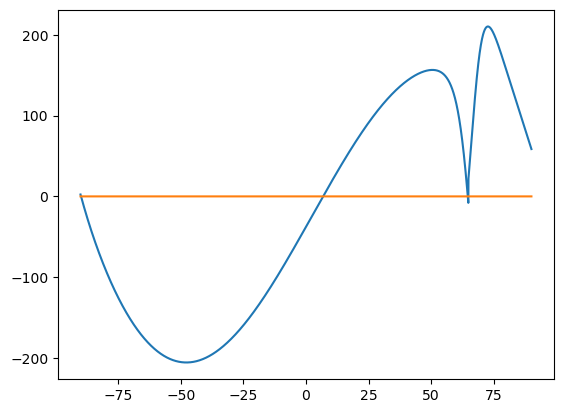

In [41]:
# f = 0 となるthetaが運動方程式の解
# phi = pi/2 とならない解を二分法で探せばよさそう
plt.plot(np.rad2deg(theta), f(theta))
plt.plot(np.rad2deg(theta), np.zeros_like(theta))


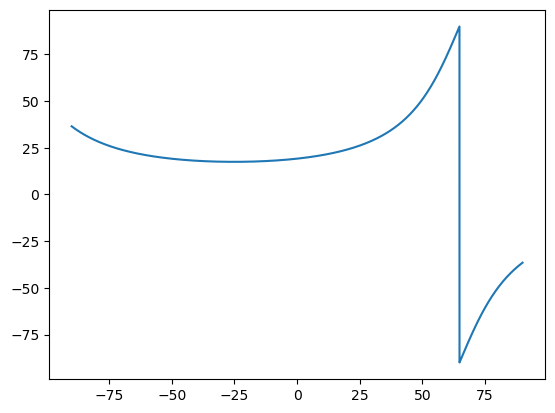

In [42]:
# ロール角
plt.plot(np.rad2deg(theta), np.rad2deg(phi(theta)))


(-10.0, 20.0)

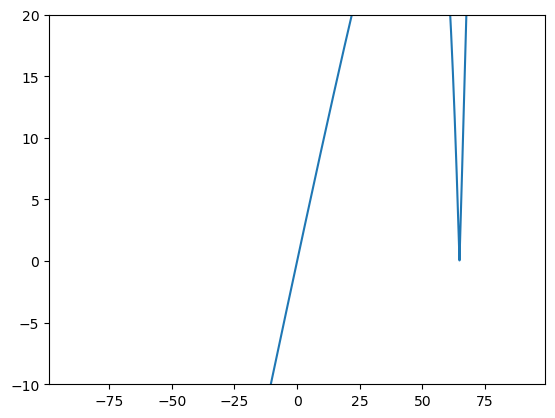

In [43]:
# 迎角
plt.plot(np.rad2deg(theta), np.rad2deg(alpha(theta)))
plt.ylim(-10., 20.)


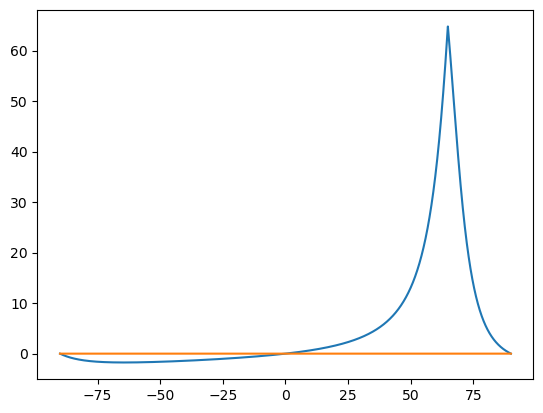

In [44]:
# 現在の飛行経路角と運動方程式の解より得られる飛行経路角の誤差
# 0になってほしいが，ならないことが多い
plt.plot(np.rad2deg(theta), np.rad2deg(theta - alpha(theta) - cur_gamma))
plt.plot(np.rad2deg(theta), np.zeros_like(theta))


(0, 49.76498789283204)

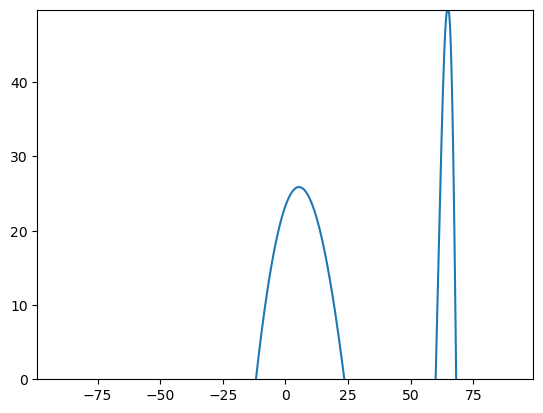

In [45]:
# 推力 [N]
T_ = T(theta)
plt.plot(np.rad2deg(theta), T_)
plt.ylim(0, max(T_))
